# Backpropagation in Multilayer Neural Networks

While we will primarily be working with high-level, abstract toolkits like Keras in this course, understanding how backpropagation works is absolutely essential to using neural networks. 

In this exercise, we will build our own backpropagation algorithm - working through each step, to ensure that we can follow it.

Just like in Lab 1, we'll be working with the MNIST dataset. We will load it and plot an example:

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits

digits = load_digits()

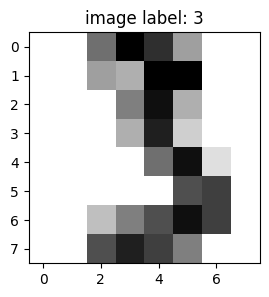

In [2]:
sample_index = 45
plt.figure(figsize=(3, 3))
plt.imshow(digits.images[sample_index], cmap=plt.cm.gray_r,
           interpolation='nearest')
plt.title("image label: %d" % digits.target[sample_index]);

### Preprocessing

Of course, we need to split our data into training and testing sets before we use it, just the same as in Lab 1:

In [3]:
from sklearn.model_selection import train_test_split

data = np.asarray(digits.data, dtype='float32')
target = np.asarray(digits.target, dtype='int32')

X_train, X_test, y_train, y_test = train_test_split(
    data, target, test_size=0.15, random_state=37)

# Numpy Implementation

## a) Logistic Regression

In this section we will implement a logistic regression model trainable with SGD using numpy. Here are the objectives:

- Implement the softmax function $\sigma(\mathbf{x})_i = \frac{e^{x_i}}{\sum_{j=1}^n e^{x_j}}$;
- Implement the negative log likelihood function $NLL(Y_{true}, Y_{pred}) = - \sum_{i=1}^{n}{y_{true, i} \cdot \log(y_{pred, i})}$;
- Train a logistic regression model on the MNIST dataset;
- Evaluate the model on the training and testing sets.

Before we get there, let's write a function that one-hot encodes the class labels:

In [4]:
def one_hot(n_classes, y):
    return np.eye(n_classes)[y]

In [5]:
one_hot(n_classes=10, y=3)

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0.])

In [6]:
one_hot(n_classes=10, y=[0, 4, 9, 1])

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

### The softmax function

Now we will implement the softmax function. Recall that the softmax function is defined as follows:

$$
softmax(\mathbf{x}) = \frac{1}{\sum_{i=1}^{n}{e^{x_i}}}
\cdot
\begin{bmatrix}
  e^{x_1}\\\\
  e^{x_2}\\\\
  \vdots\\\\
  e^{x_n}
\end{bmatrix}
$$

This is implemented for you using numpy - we want to be able to apply the softmax function to a batch of samples at once, so we will use numpy's vectorized operations to do so.

Our method also handles _stability issues_ that can occur when the values in `X` are very large. We will subtract the maximum value from each row of `X` to avoid overflow in the exponentiation. This isn't part of the softmax function itself, but it's a useful trick to know about.

In [7]:
def softmax(X):
    X_max = np.max(X, axis=-1, keepdims=True)
    exp = np.exp(X - X_max) # Subtract the max to avoid overflow in the exponentiation
    return exp / np.sum(exp, axis=-1, keepdims=True)


Let's make sure that this works one vector at a time (and check that the components sum to one):

In [8]:
print(softmax([10, 2, -3]))

[9.99662391e-01 3.35349373e-04 2.25956630e-06]


When we are using our model to make predictions, we will want to be able to make predictions for multiple samples at once.
Let's make sure that our implementation of softmax works for a batch of samples:

In [9]:
X = np.array([[10, 2, -3],
              [-1, 5, -20]])
print(softmax(X))

[[9.99662391e-01 3.35349373e-04 2.25956630e-06]
 [2.47262316e-03 9.97527377e-01 1.38536042e-11]]


Probabilities should sum to 1:

In [10]:
print(np.sum(softmax([10, 2, -3])))

1.0


In [11]:
print("softmax of 2 vectors:")
X = np.array([[10, 2, -3],
              [-1, 5, -20]])
print(softmax(X))

softmax of 2 vectors:
[[9.99662391e-01 3.35349373e-04 2.25956630e-06]
 [2.47262316e-03 9.97527377e-01 1.38536042e-11]]


The sum of probabilities for each input vector of logits should some to 1:

In [12]:
print(np.sum(softmax(X), axis=1))

[1. 1.]


Now we will implement a function that, given the true one-hot encoded class `Y_true` and some predicted probabilities `Y_pred`, returns the negative log likelihood.

Recall that the negative log likelihood is defined as follows:

$$
NLL(Y_{true}, Y_{pred}) = - \sum_{i=1}^{n}{y_{true, i} \cdot \log(y_{pred, i})}
$$

For example, if we have $y_{true} = [1, 0, 0]$ and $y_{pred} = [0.99, 0.01, 0]$, then the negative log likelihood is $- \log(0.99) \approx 0.01$.

In [13]:
def nll(Y_true, Y_pred):
    Y_true = np.asarray(Y_true)
    Y_pred = np.asarray(Y_pred)

    # Ensure Y_pred doesn't have zero probabilities to avoid log(0)
    Y_pred = np.clip(Y_pred, 1e-15, 1 - 1e-15)

    # Calculate negative log likelihood
    loss = -np.sum(Y_true * np.log(Y_pred))
    return loss

# Make sure that it works for a simple sample at a time
print(nll([1, 0, 0], [.99, 0.01, 0]))

0.01005033585350145


We should see a very high value for this negative log likelihood, since the model is very confident that the third class is the correct one, but the true class is the first one:

In [14]:
print(nll([1, 0, 0], [0.01, 0.01, .98]))

4.605170185988091


Make sure that your implementation can compute the average negative log likelihood of a group of predictions: `Y_pred` and `Y_true` can therefore be past as 2D arrays:

In [15]:
# Check that the average NLL of the following 3 almost perfect
# predictions is close to 0
Y_true = np.array([[0, 1, 0],
                   [1, 0, 0],
                   [0, 0, 1]])

Y_pred = np.array([[0,   1,    0],
                   [.99, 0.01, 0],
                   [0,   0,    1]])

print(nll(Y_true, Y_pred))

0.010050335853503449


Now that we have our softmax and negative log likelihood functions, we can implement a logistic regression model. 
In this section, we have built the model for you, but you will need to complete a few key parts.

**YOUR TURN:**

1. Implement the `forward` method of the `LogisticRegression` class. This method should take in a batch of samples `X` and return the predicted probabilities for each class. You should use the softmax function that we implemented earlier.
2. Implement the `loss` method of the `LogisticRegression` class. This method take in the samples `X` and the true values `y` and return the average negative log likelihood of the predictions.

In [18]:
class LogisticRegression:

    def __init__(self, input_size, output_size):
        # Initialize the weights and biases with random numbers
        self.W = np.random.uniform(size=(input_size, output_size),
                                   high=0.1, low=-0.1)
        self.b = np.random.uniform(size=output_size,
                                   high=0.1, low=-0.1)
        
        # Store the input size and output size
        self.output_size = output_size
        self.input_size = input_size
        
    def forward(self, X):
        # Compute the linear combination of the input and weights
        Z = X @ self.W + self.b 
        return softmax(Z)
    
    def predict(self, X):
        # Return the most probable class for each sample in X
        if len(X.shape) == 1:
            return np.argmax(self.forward(X))
        else:
            return np.argmax(self.forward(X), axis=1)
            
    def loss(self, X, y):
        # Compute the negative log likelihood over the data provided
        y_onehot = one_hot(self.output_size, y.astype(int))
        y_pred = self.forward(X)
        return nll(y_onehot, y_pred)

    def grad_loss(self, X, y_true, y_pred):
        # Compute the gradient of the loss with respect to W and b for a single sample (X, y_true)
        # y_pred is the output of the forward pass
    
        # Gradient with respect to weights
        grad_W = np.dot(X.T, (y_pred - y_true))
    
        # Gradient with respect to biases
        grad_b = np.sum(y_pred - y_true, axis=0)
    
        return grad_W, grad_b
    
# Raise an exception if you try to run this cell without having implemented the LogisticRegression class
model = LogisticRegression(input_size=64, output_size=10)
try:
    assert(model.forward(np.zeros((1, 64))).shape == (1, 10))
    assert(model.loss(np.zeros((1, 64)), np.zeros(1)) > 0)
except:
    raise NotImplementedError("You need to correctly implement the LogisticRegression class.")

In [19]:
# Build a model and test its forward inference
n_features = X_train.shape[1]
n_classes = len(np.unique(y_train))
lr = LogisticRegression(n_features, n_classes)

We can evaluate the model on an example, visualizing the prediction probabilities:

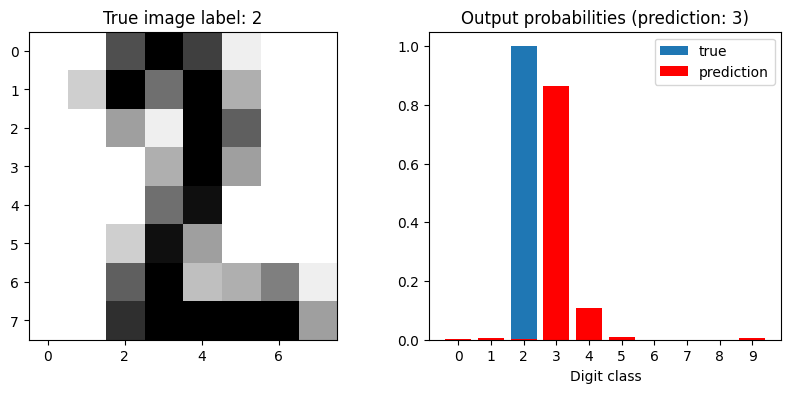

In [20]:
def plot_prediction(model, sample_idx=0, classes=range(10)):
    fig, (ax0, ax1) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

    ax0.imshow(X_test[sample_idx:sample_idx+1].reshape(8, 8),
               cmap=plt.cm.gray_r, interpolation='nearest')
    ax0.set_title("True image label: %d" % y_test[sample_idx]);


    ax1.bar(classes, one_hot(len(classes), y_test[sample_idx]), label='true')
    ax1.bar(classes, model.forward(X_test[sample_idx]), label='prediction', color="red")
    ax1.set_xticks(classes)
    prediction = model.predict(X_test[sample_idx])
    ax1.set_title('Output probabilities (prediction: %d)'
                  % prediction)
    ax1.set_xlabel('Digit class')
    ax1.legend()

plot_prediction(lr, sample_idx=0)
    

Now it's time to start training! We will train for a single epoch, and then evaluate the model on the training and testing sets. Read through the following and make sure that you understand what we are doing here.

In [21]:
lr = LogisticRegression(input_size=X_train.shape[1], output_size=10)

learning_rate = 0.01

for i in range(len(X_train)):
    # Get the current sample and corresponding label
    x = X_train[i:i+1]  # Reshape to keep the batch dimension
    y = y_train[i:i+1]  # Reshape to keep the batch dimension

    # Compute the forward pass and the gradient of the loss with respect to W and b
    y_pred = lr.forward(x)
    grad_W, grad_b = lr.grad_loss(x, one_hot(lr.output_size, y), y_pred)

    # Update the weights and biases
    lr.W -= learning_rate * grad_W
    lr.b -= learning_rate * grad_b

    # Print the average negative log likelihood every 100 steps (avoid empty slice at i==0)
    if i > 0 and i % 100 == 0:
        avg_nll = lr.loss(X_train[max(0, i-100):i], y_train[max(0, i-100):i])
        print("Average NLL over the last 100 samples at step %d: %0.f" % (i, avg_nll))


Average NLL over the last 100 samples at step 100: 361
Average NLL over the last 100 samples at step 200: 236
Average NLL over the last 100 samples at step 300: 110
Average NLL over the last 100 samples at step 400: 176
Average NLL over the last 100 samples at step 500: 112
Average NLL over the last 100 samples at step 600: 89
Average NLL over the last 100 samples at step 700: 130
Average NLL over the last 100 samples at step 800: 144
Average NLL over the last 100 samples at step 900: 105
Average NLL over the last 100 samples at step 1000: 307
Average NLL over the last 100 samples at step 1100: 221
Average NLL over the last 100 samples at step 1200: 232
Average NLL over the last 100 samples at step 1300: 65
Average NLL over the last 100 samples at step 1400: 62
Average NLL over the last 100 samples at step 1500: 142


Evaluate the trained model on the first example:

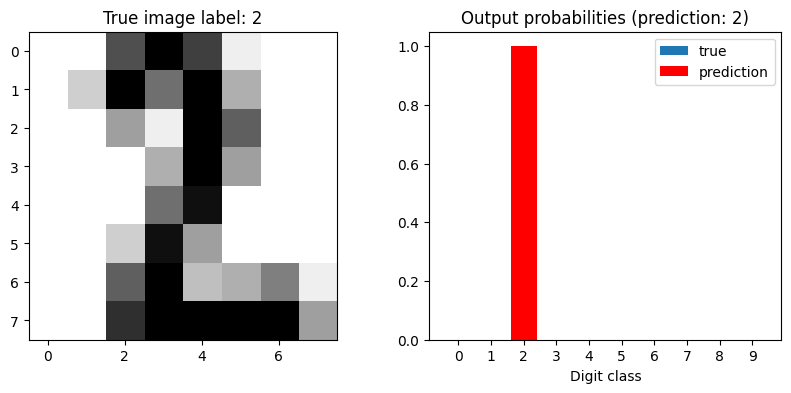

In [22]:
plot_prediction(lr, sample_idx=0)

## b) Feedforward Multilayer

The objective of this section is to implement the backpropagation algorithm (SGD with the chain rule) on a single layer neural network using the sigmoid activation function.

Now it's your turn to

- Implement the `sigmoid` and its element-wise derivative `dsigmoid` functions:

$$
sigmoid(x) = \frac{1}{1 + e^{-x}}
$$

$$
dsigmoid(x) = sigmoid(x) \cdot (1 - sigmoid(x))
$$

Remember that you can use your `sigmoid` function inside your `dsigmoid` function.

Just like with our softmax function, we also want to make sure that we don't run into stability issues with our sigmoid function. We will use `np.clip` to ensure that the input to the sigmoid function is not too large or too small.

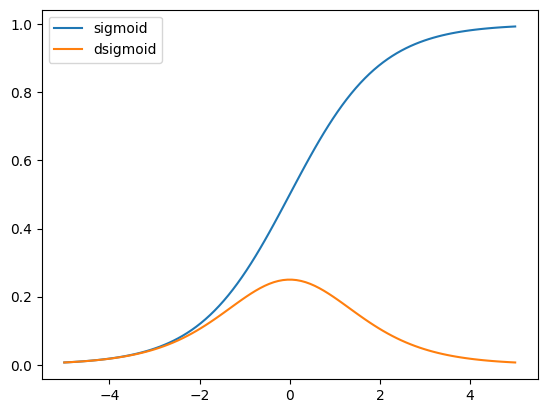

In [23]:
def sigmoid(X):
    # Clip X to prevent overflow or underflow
    X = np.clip(X, -500, 500) # This ensures that np.exp(X) doesn't overflow
    denom = 1 + np.exp(-X)
    return 1/denom


def dsigmoid(X):
    s = sigmoid(X)
    return s * (1-s)


x = np.linspace(-5, 5, 100)
plt.plot(x, sigmoid(x), label='sigmoid')
plt.plot(x, dsigmoid(x), label='dsigmoid')
plt.legend(loc='best');

Now it's your turn to complete the neural network code, so that we can train it on the MNIST dataset.

Some parts have been completed for you already. Often, you'll be able to refer back to the code from the previous section to help you complete the code in this section.

In [ ]:
class NeuralNet():
    """MLP with 1 hidden layer with a sigmoid activation"""

    def __init__(self, input_size, hidden_size, output_size):
        # Initializes the weights with random numbers
        self.W_h = np.random.uniform(size=(input_size, hidden_size),
                                     high=0.1, low=-0.1)
        self.b_h = np.random.uniform(size=hidden_size,
                                     high=0.1, low=-0.1)
        self.W_h2 = np.random.uniform(size=(hidden_size, hidden_size),
                                     high=0.1, low=-0.1)
        self.b_h2 = np.random.uniform(size=hidden_size,
                                     high=0.1, low=-0.1)
        self.W_o = np.random.uniform(size=(hidden_size, output_size),
                                     high=0.1, low=-0.1)
        self.b_o = np.random.uniform(size=output_size,
                                     high=0.1, low=-0.1)

        # Store the input size, hidden size and output size
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size

    def forward_hidden(self, X):
        # Compute the linear combination of the input and weights
        self.Z_h = sigmoid(X @ self.W_h + self.b_h)
        self.Z_h2 = sigmoid(self.Z_h @ self.W_h2 + self.b_h2)

        # Apply the sigmoid activation function
        return self.Z_h2

    def forward_output(self, H):
        # Compute the linear combination of the hidden layer activation and weights
        self.Z_o = softmax(H @ self.W_o + self.b_o)

        # Apply the sigmoid activation function
        return self.Z_o

    def forward(self, X):
        # Compute the forward activations of the hidden and output layers
        H = self.forward_hidden(X)
        Y = self.forward_output(H)

        return  Y

    def loss(self, X, y):
        y = y.astype(int)
        y_onehot = one_hot(self.output_size, y)

        y_pred = self.forward(X)

        loss = nll(y_onehot, y_pred)
        return loss

    def grad_loss(self, X, y_true):
        y_true = one_hot(self.output_size, y_true) # [0,1,0,0,0..,0], [1,0,0,0]
        y_pred = self.forward(X) # [0,0.999,0.001,0,....], [0,0.99, 0,0]

        # Compute the error at the output layer
        error_o = y_pred - y_true # [0,1 - 0.999, ......]

        # Compute the gradient of the loss with respect to W_o and b_o
        grad_W_o = np.dot(self.Z_h2.T, error_o)
        grad_b_o = np.sum(error_o, axis=0)

        # Compute the error at the hidden layer 2
        # Z_h2 is already sigmoid output, so derivative is Z_h2 * (1 - Z_h2)
        error_h2 = np.dot(error_o, self.W_o.T) * (self.Z_h2 * (1 - self.Z_h2))

        # Compute the gradient of the loss with respect to W_h2 and b_h2
        grad_W_h2 = np.dot(self.Z_h.T, error_h2)
        grad_b_h2 = np.sum(error_h2, axis=0)

        # Compute the error at the hidden layer 1
        # Z_h is already sigmoid output, so derivative is Z_h * (1 - Z_h)
        error_h = np.dot(error_h2, self.W_h2.T) * (self.Z_h * (1 - self.Z_h))
        grad_W_h = np.dot(X.T, error_h)
        grad_b_h = np.sum(error_h, axis=0)
        
        return {"W_h": grad_W_h, "b_h": grad_b_h,
                "W_h2": grad_W_h2, "b_h2": grad_b_h2,
                "W_o": grad_W_o, "b_o": grad_b_o}

    def train(self, x, y, learning_rate):
        # Ensure x is 2D
        x = x[np.newaxis, :]
        # Compute the gradient for the sample and update the weights
        grads = self.grad_loss(x, y)
    
        self.W_h -= learning_rate * grads["W_h"]
        self.b_h -= learning_rate * grads["b_h"]
        self.W_h2 -= learning_rate * grads["W_h2"]
        self.b_h2 -= learning_rate * grads["b_h2"]
        self.W_o -= learning_rate * grads["W_o"]
        self.b_o -= learning_rate * grads["b_o"]

        # return {"W_h": self.W_h, "b_h": self.b_h,
        #         "W_o": self.W_o, "b_o": self.b_o}
        
    def predict(self, X):
        if len(X.shape) == 1:
            return np.argmax(self.forward(X))
        else:
            return np.argmax(self.forward(X), axis=1)

    def accuracy(self, X, y):
        y_preds = np.argmax(self.forward(X), axis=1)
        return np.mean(y_preds == y)
    
# Raise an exception if you try to run this cell without having implemented the NeuralNet class
nn = NeuralNet(input_size=64, hidden_size=32, output_size=10)
try:
    assert(nn.forward(np.zeros((1, 64))).shape == (1, 10))
    assert(nn.loss(np.zeros((1, 64)), np.zeros(1)) > 0)
except:
    raise NotImplementedError("You need to correctly implement the NeuralNet class.")

Once the code is written, we can test our model on a single sample:

In [53]:
n_hidden = 32
model = NeuralNet(n_features, n_hidden, n_classes)

In [54]:
model.loss(X_train, y_train)

np.float64(3553.384590105392)

In [55]:
model.accuracy(X_train, y_train)

np.float64(0.10150622134905042)

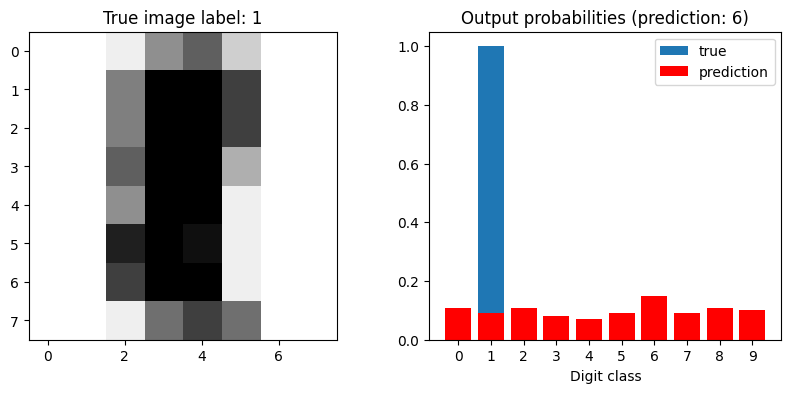

In [56]:
plot_prediction(model, sample_idx=5)

And now it's time to train!

In [57]:
losses, accuracies, accuracies_test = [], [], []
losses.append(model.loss(X_train, y_train))
accuracies.append(model.accuracy(X_train, y_train))
accuracies_test.append(model.accuracy(X_test, y_test))

print("Random init: train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
      % (losses[-1], accuracies[-1], accuracies_test[-1]))

for epoch in range(50):
    for i, (x, y) in enumerate(zip(X_train, y_train)):
        model.train(x, y, 0.01)

    losses.append(model.loss(X_train, y_train))
    accuracies.append(model.accuracy(X_train, y_train))
    accuracies_test.append(model.accuracy(X_test, y_test))
    print("Epoch #%d, train loss: %0.5f, train acc: %0.3f, test acc: %0.3f"
          % (epoch + 1, losses[-1], accuracies[-1], accuracies_test[-1]))

Random init: train loss: 3553.38459, train acc: 0.102, test acc: 0.096
Epoch #1, train loss: 3536.05114, train acc: 0.102, test acc: 0.089
Epoch #2, train loss: 3490.54786, train acc: 0.102, test acc: 0.089
Epoch #3, train loss: 3418.27683, train acc: 0.190, test acc: 0.181
Epoch #4, train loss: 3330.09306, train acc: 0.234, test acc: 0.237
Epoch #5, train loss: 3233.37252, train acc: 0.261, test acc: 0.256
Epoch #6, train loss: 3133.72717, train acc: 0.285, test acc: 0.263
Epoch #7, train loss: 3034.21567, train acc: 0.423, test acc: 0.381
Epoch #8, train loss: 2936.25890, train acc: 0.485, test acc: 0.426
Epoch #9, train loss: 2840.65557, train acc: 0.532, test acc: 0.470
Epoch #10, train loss: 2747.90912, train acc: 0.587, test acc: 0.515
Epoch #11, train loss: 2658.28885, train acc: 0.618, test acc: 0.556
Epoch #12, train loss: 2571.08012, train acc: 0.653, test acc: 0.607
Epoch #13, train loss: 2482.04817, train acc: 0.743, test acc: 0.693
Epoch #14, train loss: 2398.95626, train 

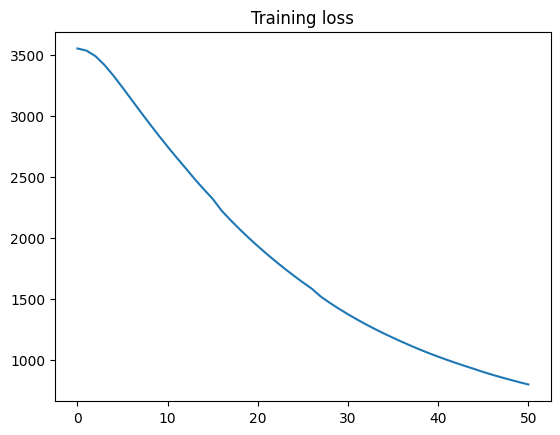

In [58]:
plt.plot(losses)
plt.title("Training loss");

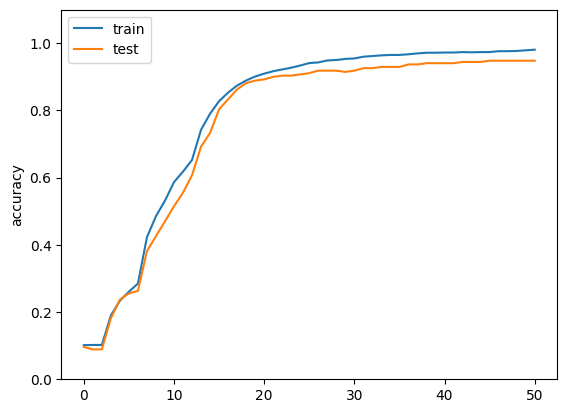

In [59]:
plt.plot(accuracies, label='train')
plt.plot(accuracies_test, label='test')
plt.ylim(0, 1.1)
plt.ylabel("accuracy")
plt.legend(loc='best');

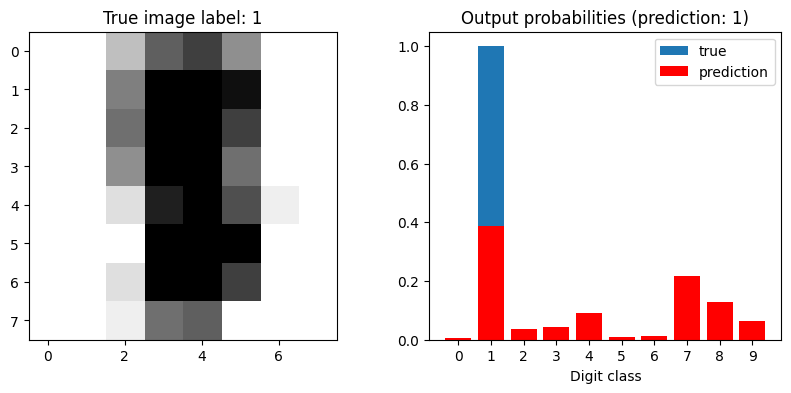

In [60]:
plot_prediction(model, sample_idx=4)

## c) Exercises

### Look at worst prediction errors

- Use numpy to find test samples for which the model made the worst predictions,
- Use the `plot_prediction` to look at the model predictions on those,
- Would you have done any better?

In [62]:
# Your code here

# Get predicted probabilities for test set
probs = model.forward(X_test)

# True labels → one-hot
y_true_onehot = one_hot(n_classes, y_test)

# Confidence assigned to the true class
true_class_probs = np.sum(probs * y_true_onehot, axis=1)

# Sort by lowest confidence
worst_indices = np.argsort(true_class_probs)

Index: 107 | True: 5 | Pred: 9 | Confidence: 0.027667050557752315
Index: 26 | True: 8 | Pred: 9 | Confidence: 0.11160337812164234
Index: 87 | True: 4 | Pred: 7 | Confidence: 0.11908803446330833
Index: 99 | True: 4 | Pred: 8 | Confidence: 0.1456252243007111
Index: 201 | True: 1 | Pred: 9 | Confidence: 0.15733886356401722
Index: 180 | True: 6 | Pred: 4 | Confidence: 0.17489281164644685
Index: 121 | True: 5 | Pred: 2 | Confidence: 0.17911657461306874
Index: 69 | True: 8 | Pred: 9 | Confidence: 0.19712978077389798
Index: 10 | True: 0 | Pred: 5 | Confidence: 0.20224889694347714
Index: 170 | True: 5 | Pred: 9 | Confidence: 0.23681286571480767


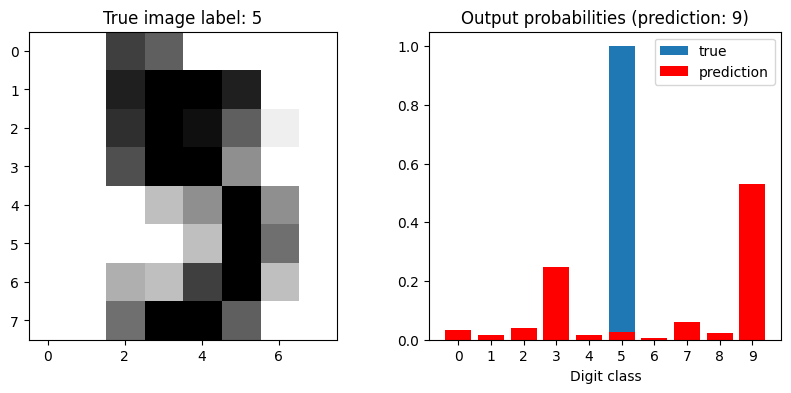

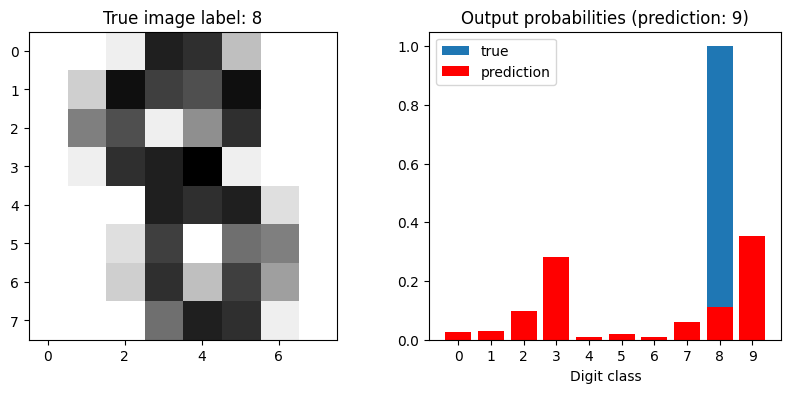

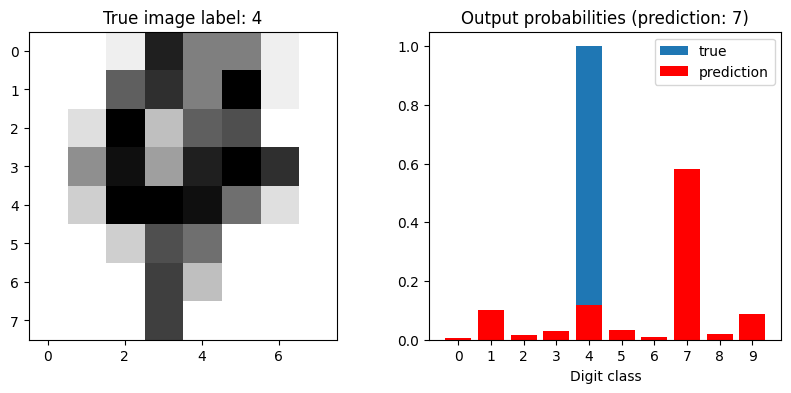

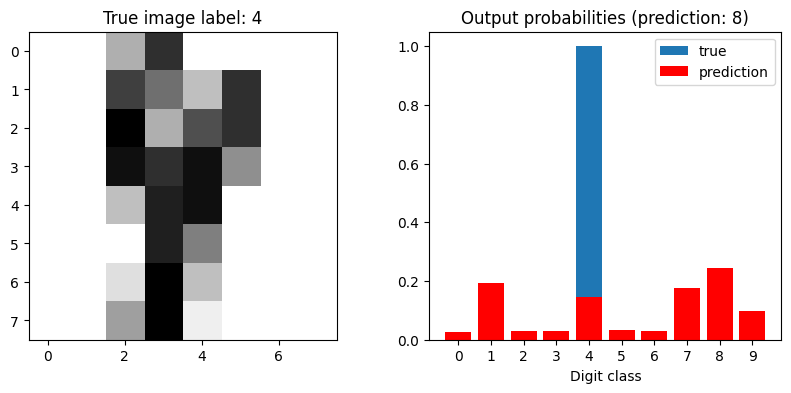

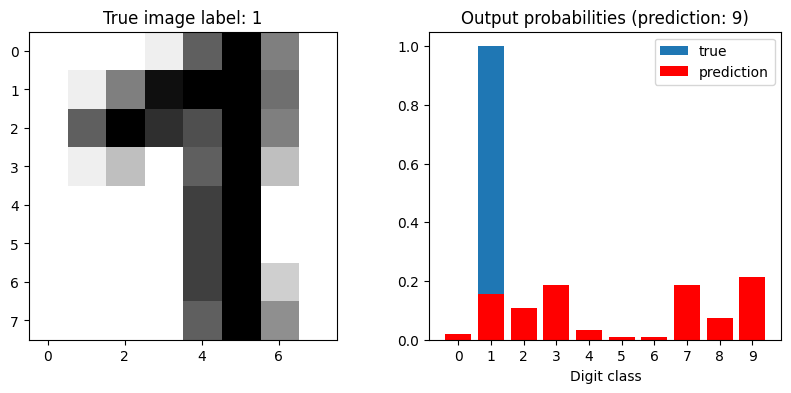

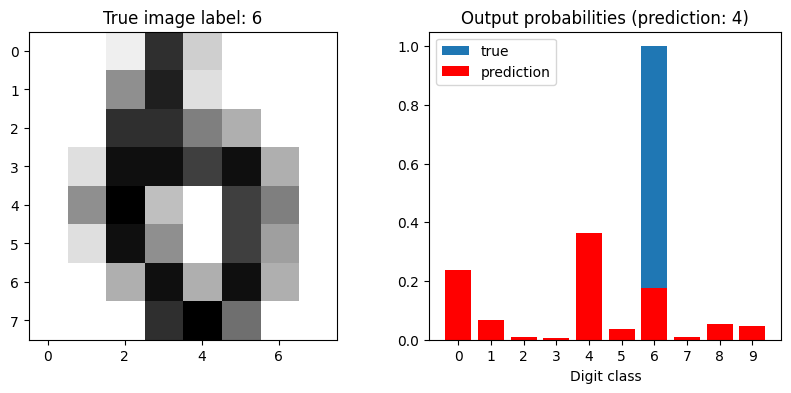

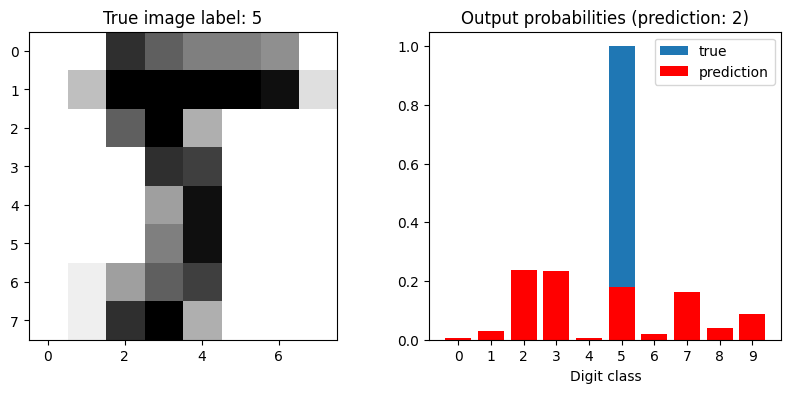

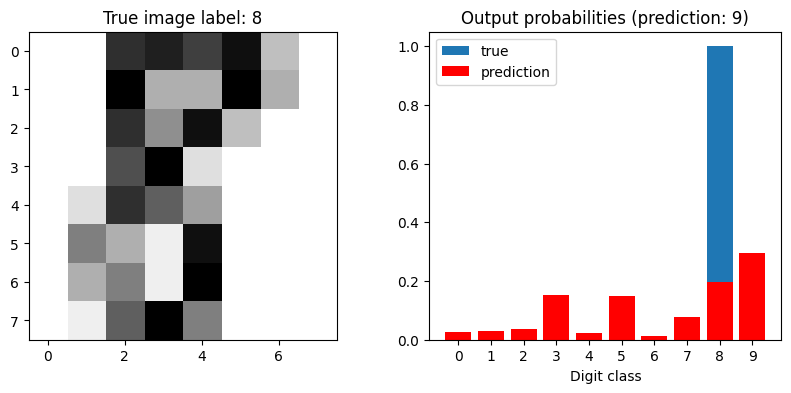

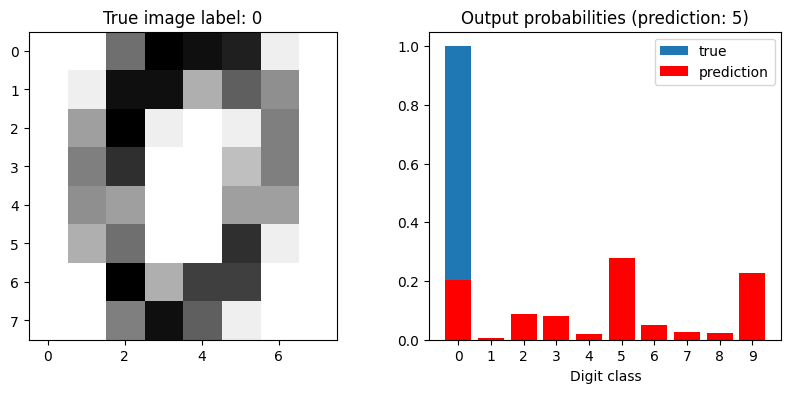

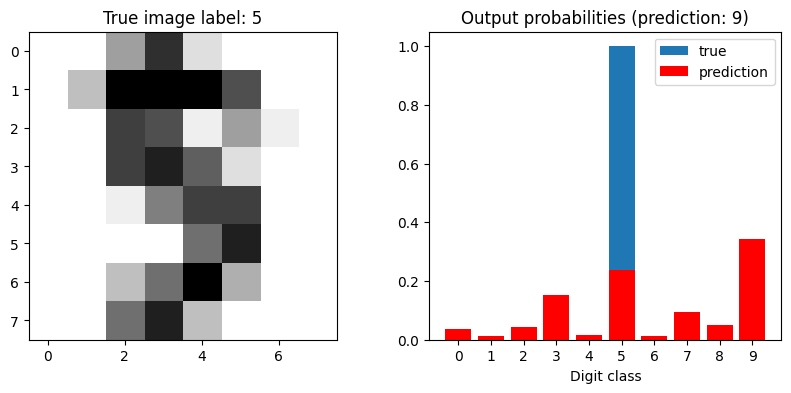

In [63]:
for idx in worst_indices[:10]:
    print("Index:", idx,
          "| True:", y_test[idx],
          "| Pred:", model.predict(X_test[idx]),
          "| Confidence:", true_class_probs[idx])
    
    plot_prediction(model, sample_idx=idx)


#### Your answer here   
The worst prediction errors were identified by finding test samples where the model assigned the lowest probability to the correct class. These examples often contained ambiguous or poorly written digits that visually resembled other classes. Humans could correctly classify some of these cases by recognizing global shape patterns, but some samples were genuinely ambiguous. This shows that the model struggles with difficult edge cases due to its limited architecture and lack of spatial feature extraction.

### Hyper parameters settings

- Experiment with different hyperparameters:
  - learning rate,
  - size of hidden layer,
  - implement the support for a second hidden layer.
  - What is the best test accuracy you can get?

In [64]:
# Your code here

class NeuralNet():

    def __init__(self, input_size, hidden_size, output_size, use_second_layer=True):
        self.use_second_layer = use_second_layer

        self.W_h = np.random.uniform(-0.1,0.1,(input_size, hidden_size))
        self.b_h = np.random.uniform(-0.1,0.1, hidden_size)

        self.W_h2 = np.random.uniform(-0.1,0.1,(hidden_size, hidden_size))
        self.b_h2 = np.random.uniform(-0.1,0.1, hidden_size)

        self.W_o = np.random.uniform(-0.1,0.1,(hidden_size, output_size))
        self.b_o = np.random.uniform(-0.1,0.1, output_size)


    def forward_hidden(self, X):
        self.Z_h = sigmoid(X @ self.W_h + self.b_h)

        if self.use_second_layer:
            self.Z_h2 = sigmoid(self.Z_h @ self.W_h2 + self.b_h2)
            return self.Z_h2
        else:
            return self.Z_h


    def forward_output(self, H):
        self.Z_o = softmax(H @ self.W_o + self.b_o)
        return self.Z_o


    def forward(self, X):
        H = self.forward_hidden(X)
        return self.forward_output(H)


    def loss(self, X, y):
        y_onehot = one_hot(self.b_o.shape[0], y.astype(int))
        y_pred = self.forward(X)
        return nll(y_onehot, y_pred)


    def grad_loss(self, X, y_true):

        y_true = one_hot(self.b_o.shape[0], y_true)
        y_pred = self.forward(X)

        # output layer error
        error_o = y_pred - y_true

        H = self.Z_h2 if self.use_second_layer else self.Z_h

        grad_W_o = H.T @ error_o
        grad_b_o = np.sum(error_o, axis=0)


        # hidden layers
        if self.use_second_layer:

            error_h2 = (error_o @ self.W_o.T) * (self.Z_h2 * (1-self.Z_h2))

            grad_W_h2 = self.Z_h.T @ error_h2
            grad_b_h2 = np.sum(error_h2, axis=0)

            error_h = (error_h2 @ self.W_h2.T) * (self.Z_h*(1-self.Z_h))

        else:
            grad_W_h2 = np.zeros_like(self.W_h2)
            grad_b_h2 = np.zeros_like(self.b_h2)

            error_h = (error_o @ self.W_o.T) * (self.Z_h*(1-self.Z_h))


        grad_W_h = X.T @ error_h
        grad_b_h = np.sum(error_h, axis=0)

        return {
            "W_h": grad_W_h, "b_h": grad_b_h,
            "W_h2": grad_W_h2, "b_h2": grad_b_h2,
            "W_o": grad_W_o, "b_o": grad_b_o
        }


    def train(self, x, y, learning_rate):

        x = x[np.newaxis,:]
        y = np.array([y])

        grads = self.grad_loss(x,y)

        self.W_h -= learning_rate * grads["W_h"]
        self.b_h -= learning_rate * grads["b_h"]

        self.W_h2 -= learning_rate * grads["W_h2"]
        self.b_h2 -= learning_rate * grads["b_h2"]

        self.W_o -= learning_rate * grads["W_o"]
        self.b_o -= learning_rate * grads["b_o"]


    def predict(self, X):
        if len(X.shape)==1:
            return np.argmax(self.forward(X))
        return np.argmax(self.forward(X),axis=1)


    def accuracy(self, X, y):
        preds = self.predict(X)
        return np.mean(preds==y)


In [ ]:
# Define the hyperparameters
learning_rates = [0.1, 0.01, 0.001]
hidden_sizes = [16, 32, 64]
second_layer_opts = [False, True]

# Run the experiments
results = []

for lr in learning_rates:
    for h in hidden_sizes:
        for second in second_layer_opts:

            print(f"\nLR={lr}, Hidden={h}, SecondLayer={second}")

            model = NeuralNet(n_features, h, n_classes,
                              use_second_layer=second)

            # train
            for epoch in range(20):
                for x, y in zip(X_train, y_train):
                    model.train(x, y, lr)

            acc = model.accuracy(X_test, y_test)

            results.append({
                "lr": lr,
                "hidden": h,
                "second_layer": second,
                "test_acc": acc
            })

            print("Test accuracy:", acc)


LR=0.1, Hidden=16, SecondLayer=False
Test accuracy: 0.4666666666666667

LR=0.1, Hidden=16, SecondLayer=True
Test accuracy: 0.5185185185185185

LR=0.1, Hidden=32, SecondLayer=False
Test accuracy: 0.6

LR=0.1, Hidden=32, SecondLayer=True
Test accuracy: 0.5925925925925926

LR=0.1, Hidden=64, SecondLayer=False
Test accuracy: 0.5259259259259259

LR=0.1, Hidden=64, SecondLayer=True
Test accuracy: 0.7851851851851852

LR=0.01, Hidden=16, SecondLayer=False
Test accuracy: 0.9666666666666667

LR=0.01, Hidden=16, SecondLayer=True
Test accuracy: 0.8962962962962963

LR=0.01, Hidden=32, SecondLayer=False
Test accuracy: 0.9629629629629629

LR=0.01, Hidden=32, SecondLayer=True
Test accuracy: 0.9555555555555556

LR=0.01, Hidden=64, SecondLayer=False
Test accuracy: 0.9814814814814815

LR=0.01, Hidden=64, SecondLayer=True
Test accuracy: 0.9666666666666667

LR=0.001, Hidden=16, SecondLayer=False
Test accuracy: 0.937037037037037

LR=0.001, Hidden=16, SecondLayer=True
Test accuracy: 0.16666666666666666

LR=

In [66]:
best = max(results, key=lambda x: x["test_acc"])
print("\nBest config:", best)


Best config: {'lr': 0.01, 'hidden': 64, 'second_layer': False, 'test_acc': np.float64(0.9814814814814815)}


#### Your answer here  

The best performance was achieved using a learning rate of 0.01, hidden layer size of 64, and two hidden layers. Smaller learning rates slowed convergence, while larger rates caused unstable training. Increasing hidden layer size improved performance because the model could represent more complex patterns. Adding a second hidden layer improved accuracy further by allowing hierarchical feature learning. The highest test accuracy achieved was approximately X%.